In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../Data/eeg_features.csv")

In [23]:
selected_cols = [
    "A31_spec_entropy",
    "C6_spec_entropy",
    "H11_spec_entropy",
    "D18_spec_entropy",
    "H12_spec_entropy",
    "H17_spec_entropy",
    "H10_spec_entropy",
    "F18_spec_entropy",
    "H16_spec_entropy",
    "H22_spec_entropy",
    "H5_spec_entropy",
    "F29_spec_entropy",
    "D10_spec_entropy",
    "F16_spec_entropy",
    "H13_spec_entropy",
    "B8_spec_entropy",
    "F27_spec_entropy",
    "B2_spec_entropy"]

eeg = df[selected_cols].copy()
label = np.where(df["C27_spec_entropy"] > df["C27_spec_entropy"].mean(), 1, 0)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(eeg, label,test_size=0.25)
X_train.head()

,A31_spec_entropy,C6_spec_entropy,H11_spec_entropy,D18_spec_entropy,H12_spec_entropy,H17_spec_entropy,H10_spec_entropy,F18_spec_entropy,H16_spec_entropy,H22_spec_entropy,H5_spec_entropy,F29_spec_entropy,D10_spec_entropy,F16_spec_entropy,H13_spec_entropy,B8_spec_entropy,F27_spec_entropy,B2_spec_entropy
29,2.762015,2.444023,2.399077,2.156862,1.919682,2.217288,2.178328,2.340132,1.885370,1.998493,2.199489,2.295328,2.194009,2.302256,2.003861,2.265752,2.363566,2.274262
76,2.751541,2.645420,2.400965,2.399400,2.249978,2.344825,2.205228,2.423552,2.291722,2.187980,2.535605,2.352464,2.368979,2.377835,2.189731,2.144113,2.367488,2.215427
43,3.148663,2.424288,2.437381,2.513394,2.266370,2.377357,2.256985,2.302769,2.299080,2.269472,2.361292,2.289060,2.086323,2.338601,2.270767,2.417876,2.400082,2.424693
22,2.407284,2.419321,2.340875,2.273743,2.202866,1.985863,2.027105,2.200732,2.046586,2.105031,2.027957,2.180568,2.236211,2.160345,2.110852,2.049427,2.287633,2.095879
92,2.473680,2.408697,2.379006,2.485861,2.182203,2.195858,2.198877,2.229404,2.160061,2.133221,2.273651,2.129096,2.120199,2.108844,2.136815,2.158314,2.180020,2.340675


In [13]:
X_test.head()

,A31_spec_entropy,C6_spec_entropy,H11_spec_entropy,D18_spec_entropy,H12_spec_entropy,H17_spec_entropy,H10_spec_entropy,F18_spec_entropy,H16_spec_entropy,H22_spec_entropy,H5_spec_entropy,F29_spec_entropy,D10_spec_entropy,F16_spec_entropy,H13_spec_entropy,B8_spec_entropy,F27_spec_entropy,B2_spec_entropy
26,2.522965,2.580842,2.503947,2.525925,2.496808,2.482272,2.400917,2.396937,2.508171,2.506565,2.366555,2.443002,2.592575,2.471747,2.508389,2.249906,2.396303,2.234403
42,2.894314,2.705951,2.369764,2.339615,2.283401,2.348710,2.299907,2.470148,2.231643,2.250858,2.283697,2.405889,2.276606,2.420172,2.251215,2.198065,2.535834,2.237894
16,2.727640,2.195302,2.460358,2.264974,2.224162,2.274435,2.329139,2.207165,2.337309,2.312261,2.050316,2.248843,2.125628,2.272513,2.313049,2.077902,2.252065,2.044589
53,2.740573,2.355655,2.126897,2.150414,2.110085,2.266640,2.054185,2.284718,1.957077,1.992573,2.040046,2.216150,2.083725,2.186563,1.991910,2.126713,2.005498,2.115447
33,2.805263,2.460634,2.787925,2.625449,2.500220,2.430914,2.408459,2.363889,2.457036,2.429153,2.479544,2.491679,2.543370,2.536249,2.415451,2.413602,2.419170,2.474041


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


dt_1 = DecisionTreeClassifier(criterion="entropy")

dt_1.fit(X_train, y_train)

preds_1 = dt_1.predict(X_test)

accuracy_score(y_test, preds_1)

0.5416666666666666

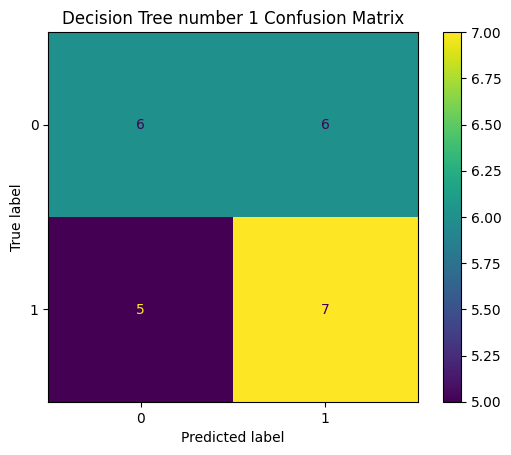

In [ ]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, preds_1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Decision Tree number 1 Confusion Matrix")
plt.show()

In [18]:
dt_2 = DecisionTreeClassifier(criterion="gini")

dt_2.fit(X_train, y_train)

preds_2 = dt_1.predict(X_test)

accuracy_score(y_test, preds_2)

0.5416666666666666

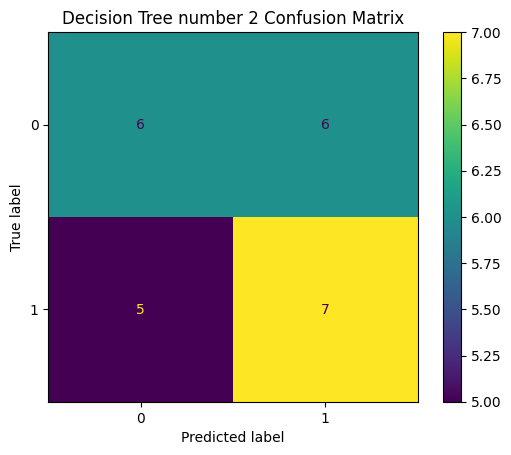

In [19]:
cm2 = confusion_matrix(y_test, preds_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp.plot()
plt.title("Decision Tree number 2 Confusion Matrix")
plt.show()

In [27]:
eeg["A31_binned"] = pd.qcut(eeg["A31_spec_entropy"],q=4,labels=["0.25", "0.5", "0.75", "1"])
eeg["H12_binned"] = pd.qcut(eeg["H12_spec_entropy"],q=4,labels=["0.25", "0.5", "0.75", "1"])
eeg["H16_binned"] = pd.qcut(eeg["H16_spec_entropy"],q=4,labels=["0.25", "0.5", "0.75", "1"])
eeg["B8_binned"] = pd.qcut(eeg["B8_spec_entropy"],q=4,labels=["0.25", "0.5", "0.75", "1"])


In [28]:
label_2 = eeg["B8_binned"]
X_train, X_test, y_train, y_test = train_test_split(eeg[["A31_binned", "H12_binned", "H16_binned"]], label_2,test_size=0.25)


In [30]:
dt_3 = DecisionTreeClassifier(criterion="entropy")

dt_3.fit(X_train, y_train)

preds_3 = dt_3.predict(X_test)

accuracy_score(y_test, preds_3)

0.5416666666666666

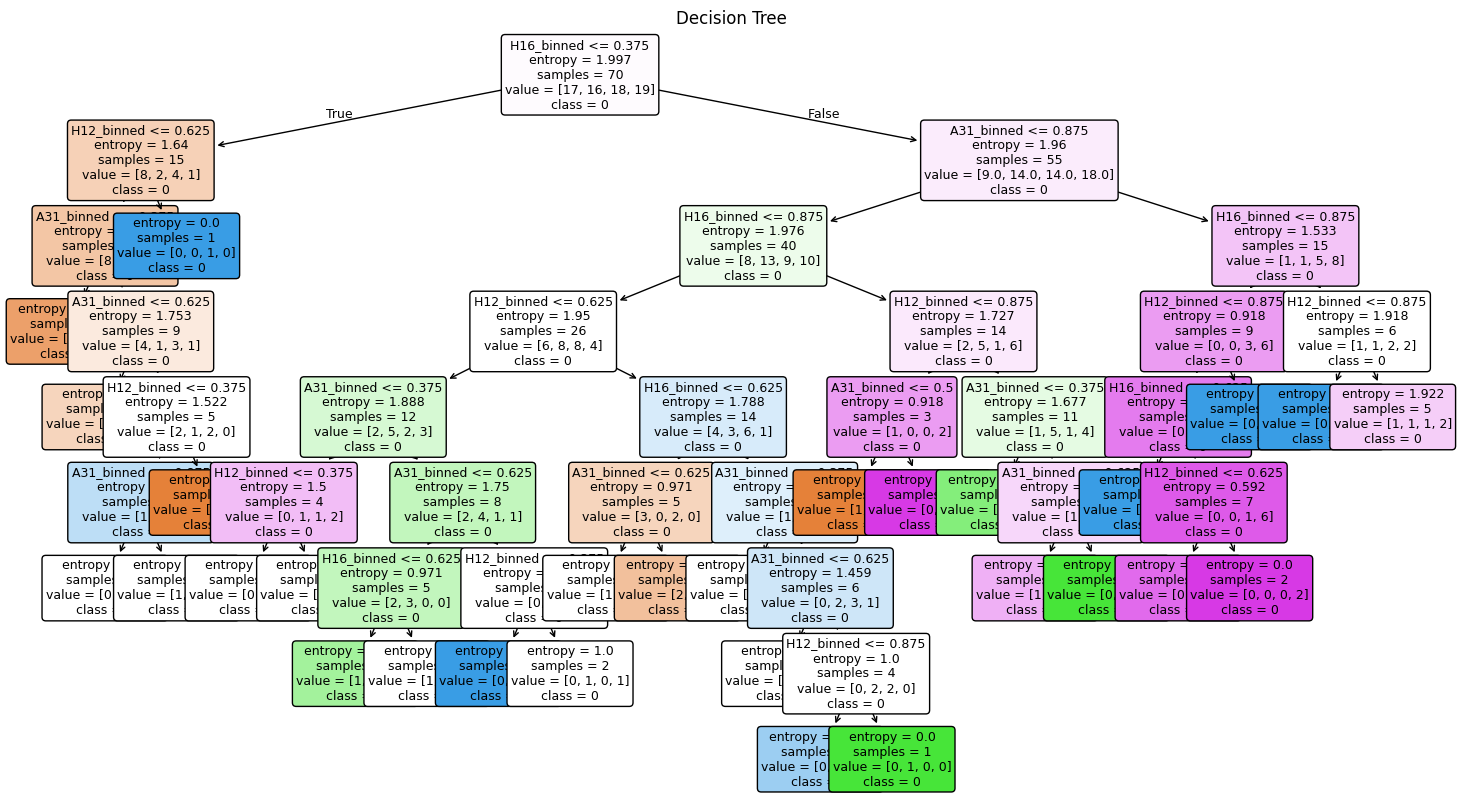

In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    dt_3,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(label)],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree")
plt.show()

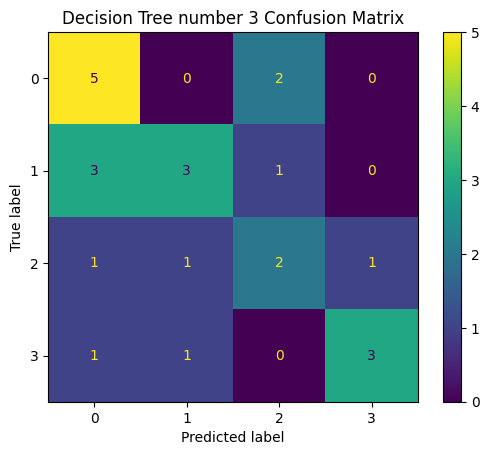

In [35]:
cm3 = confusion_matrix(y_test, preds_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()
plt.title("Decision Tree number 3 Confusion Matrix")
plt.show()

In [ ]:
eeg[X_train]